# Segmentación de consumidores y posicionamiento de marca con K-Means

**Trabajo de titulación — Instituto de Estadística, PUCV (2025)**
Autor: José Barrientos Álvarez

Este notebook segmenta consumidores de aparatos electrónicos según su percepción de marca,
usando clustering K-Means sobre evaluaciones en escala Likert de 7 puntos, con el fin de
orientar decisiones de posicionamiento.

**Flujo:** carga de datos → análisis exploratorio → método del codo → K-Means (k=4) →
caracterización de segmentos → distribución de marcas por segmento → conclusiones.

## 1. Importaciones y configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

RANDOM_STATE = 42
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

## 2. Carga de datos

La base proviene de *Multivariate Data Analysis* (Hair et al., 2010). Contiene 3.050
evaluaciones de consumidores sobre 4 marcas de aparatos electrónicos (anonimizadas como
Romeo, Sierra, Papa y Tango), medidas en 9 atributos perceptuales en escala Likert de 1 a 7.

In [2]:
DATA_PATH = "BaseTrabajoDeTitulo_.xlsx"

df = pd.read_excel(DATA_PATH)
df.columns = [c.strip() for c in df.columns]

LIKERT_VARS = ["Adaptable", "BestValue", "CuttingEdge", "Delightful", "Exciting",
               "Friendly", "Generous", "Helpful", "Intuitive"]
BRAND_COL = "Brand"

print(f"Observaciones: {df.shape[0]}  |  Variables: {df.shape[1]}")
df.head()

Observaciones: 3050  |  Variables: 10


,Adaptable,BestValue,CuttingEdge,Delightful,Exciting,Friendly,Generous,Helpful,Intuitive,Brand
0,6,5,4,4,3,4,5,4,3,Sierra
1,4,3,4,2,4,4,5,2,5,Romeo
2,3,2,3,6,5,5,6,4,3,Sierra
3,4,1,4,4,5,4,5,3,3,Sierra
4,4,1,3,3,3,5,5,4,4,Sierra


## 3. Análisis exploratorio

### 3.1 Distribución de encuestados por marca

Romeo y Sierra concentran la mayoría de las evaluaciones. Esta desigualdad se retoma
en las limitaciones del estudio.

Cantidad de encuestados por marca:
Brand
Romeo     1174
Sierra    1119
Papa       450
Tango      307
Name: count, dtype: int64

Proporción (%):
Brand
Romeo     38.49
Sierra    36.69
Papa      14.75
Tango     10.07
Name: count, dtype: float64


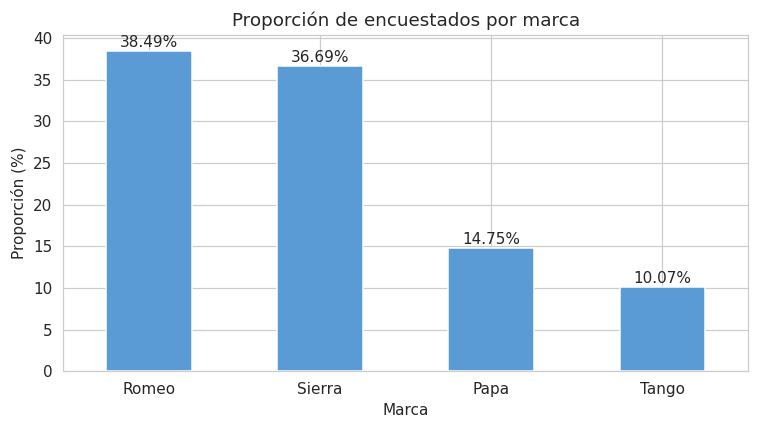

In [3]:
brand_counts = df[BRAND_COL].value_counts()
brand_props = (brand_counts / brand_counts.sum() * 100).round(2)

print("Cantidad de encuestados por marca:")
print(brand_counts)
print("\nProporción (%):")
print(brand_props)

ax = brand_props.plot(kind="bar", color="#5B9BD5", figsize=(7,4))
ax.set_title("Proporción de encuestados por marca")
ax.set_ylabel("Proporción (%)")
ax.set_xlabel("Marca")
for i, v in enumerate(brand_props):
    ax.text(i, v + 0.5, f"{v:.2f}%", ha="center")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 3.2 Top por atributo (mejor y peor evaluadas)

Para cada atributo se identifica qué marca tiene mayor proporción de evaluaciones altas
(6–7) y cuál mayor proporción de evaluaciones bajas (1–2).

In [4]:
def prop_top2(x):
    x = pd.to_numeric(x, errors="coerce")
    return np.mean(np.isin(x, [6, 7]))

def prop_bot2(x):
    x = pd.to_numeric(x, errors="coerce")
    return np.mean(np.isin(x, [1, 2]))

rows = []
for v in LIKERT_VARS:
    top2 = df.groupby(BRAND_COL)[v].apply(prop_top2)
    bot2 = df.groupby(BRAND_COL)[v].apply(prop_bot2)
    rows.append({"Variable": v, "Mejor (6-7)": top2.idxmax(), "Peor (1-2)": bot2.idxmax()})

top_table = pd.DataFrame(rows)
top_table

,Variable,Mejor (6-7),Peor (1-2)
0,Adaptable,Papa,Sierra
1,BestValue,Tango,Papa
2,CuttingEdge,Tango,Papa
3,Delightful,Tango,Papa
4,Exciting,Tango,Papa
5,Friendly,Papa,Tango
6,Generous,Tango,Papa
7,Helpful,Papa,Tango
8,Intuitive,Papa,Tango


**Lectura:** Papa y Tango concentran las mejores evaluaciones. Papa destaca en atributos
funcionales (intuitiva, útil, confiable); Tango en atributos emocionales y de innovación
(emocionante, agradable, mejor relación valor-precio).

## 4. Preparación para clustering

Las variables se estandarizan para que todas pesen igual en el cálculo de distancias
euclidianas usado por K-Means.

In [5]:
X = df[LIKERT_VARS].copy()
X_scaled = StandardScaler().fit_transform(X)
print("Matriz estandarizada:", X_scaled.shape)

Matriz estandarizada: (3050, 9)


## 5. Método del codo

Se ajusta K-Means para distintos valores de k y se grafica la inercia (suma de cuadrados
intra-grupo). El "codo" indica el punto donde añadir más grupos deja de mejorar
sustancialmente el modelo.

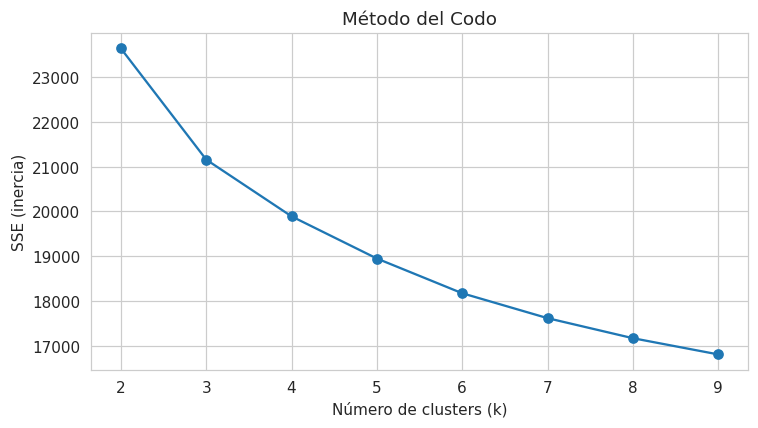

In [6]:
inertias = []
ks = range(2, 10)
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(list(ks), inertias, marker="o")
plt.title("Método del Codo")
plt.xlabel("Número de clusters (k)")
plt.ylabel("SSE (inercia)")
plt.tight_layout()
plt.show()

Entre k=3 y k=4 la caída de inercia es similar. Se probaron ambos: con k=3 los grupos
resultaban poco diferenciables, mientras que **k=4** produjo segmentos más definidos e
interpretables. Por eso se selecciona k=4.

## 6. K-Means con k=4

In [7]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

cluster_sizes = df["cluster"].value_counts().sort_index()
print("Tamaño de cada cluster:")
print(cluster_sizes)
print("\nLos tamaños son equilibrados, lo que refuerza la estabilidad del modelo.")

Tamaño de cada cluster:
cluster
0    719
1    784
2    714
3    833
Name: count, dtype: int64

Los tamaños son equilibrados, lo que refuerza la estabilidad del modelo.


## 7. Caracterización de los segmentos

Se calcula el perfil promedio de cada cluster en los 9 atributos. El heatmap permite leer
de un vistazo en qué se diferencia cada grupo.

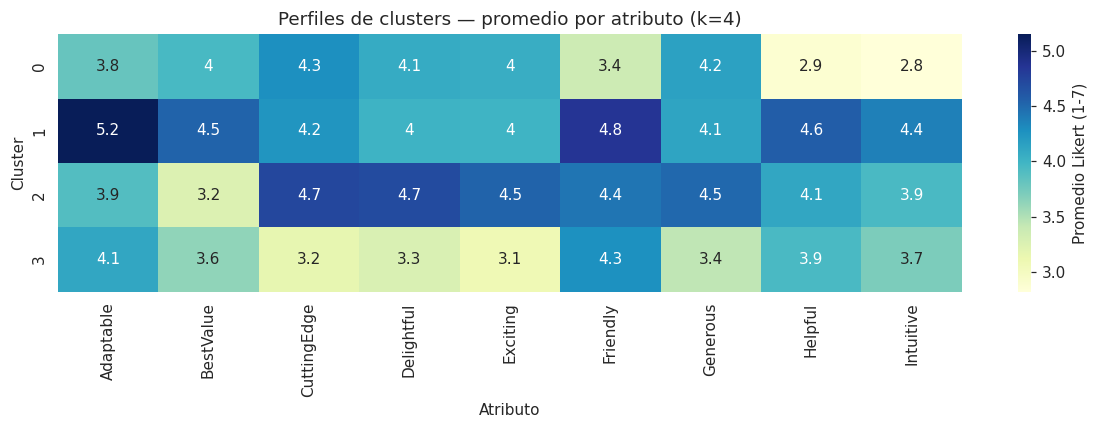

,Adaptable,BestValue,CuttingEdge,Delightful,Exciting,Friendly,Generous,Helpful,Intuitive
cluster,,,,,,,,,
0,3.81,3.95,4.28,4.07,4.05,3.36,4.15,2.88,2.82
1,5.15,4.54,4.24,4.01,4.00,4.85,4.13,4.57,4.37
2,3.90,3.24,4.73,4.70,4.54,4.44,4.51,4.11,3.94
3,4.11,3.63,3.16,3.27,3.09,4.27,3.43,3.94,3.71


In [8]:
profiles = df.groupby("cluster")[LIKERT_VARS].mean().round(2)

plt.figure(figsize=(11,4))
sns.heatmap(profiles, annot=True, cmap="YlGnBu", cbar_kws={"label": "Promedio Likert (1-7)"})
plt.title("Perfiles de clusters — promedio por atributo (k=4)")
plt.ylabel("Cluster")
plt.xlabel("Atributo")
plt.tight_layout()
plt.show()

profiles

**Interpretación de los segmentos.** Los consumidores se dividen en cuatro lógicas de
percepción:

- Un grupo orientado a la **innovación**, que valora el avance tecnológico pero percibe
  las marcas como poco intuitivas.
- Un grupo orientado a la **funcionalidad**, que busca utilidad, servicio y confiabilidad
  antes que novedad.
- Un grupo con percepción **equilibrada**, que combina confianza, funcionalidad e
  innovación, y muestra los puntajes promedio más altos.
- Un grupo orientado a la **emoción y novedad**, atraído por marcas modernas y dinámicas.

## 8. Distribución de marcas dentro de cada segmento

Permite ver qué marca predomina en cada perfil de consumidor.

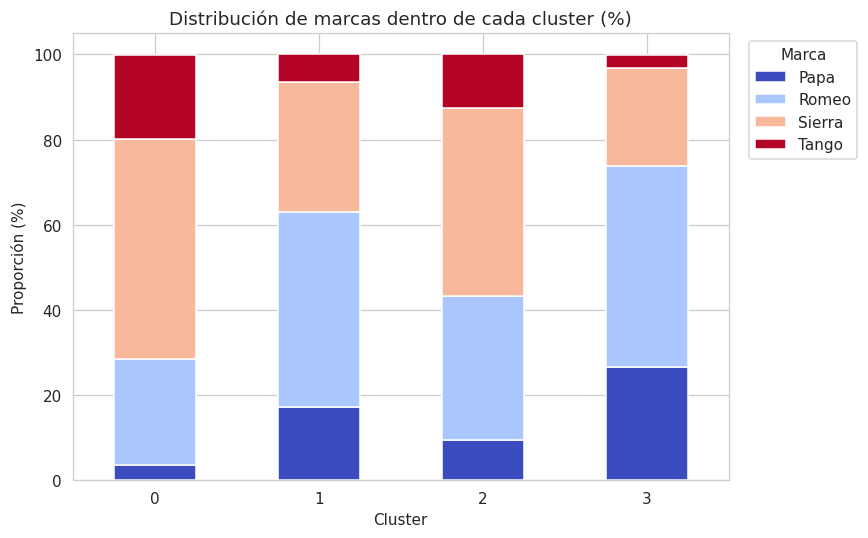

Brand,Papa,Romeo,Sierra,Tango
cluster,,,,
0,3.5,25.0,51.7,19.7
1,17.3,45.7,30.6,6.4
2,9.5,33.8,44.1,12.6
3,26.5,47.4,23.0,3.0


In [9]:
dist = (df.groupby("cluster")[BRAND_COL]
          .value_counts(normalize=True)
          .mul(100).round(1)
          .rename("pct")
          .reset_index())

pivot = dist.pivot(index="cluster", columns=BRAND_COL, values="pct").fillna(0)

pivot.plot(kind="bar", stacked=True, figsize=(8,5), colormap="coolwarm")
plt.title("Distribución de marcas dentro de cada cluster (%)")
plt.ylabel("Proporción (%)")
plt.xlabel("Cluster")
plt.legend(title="Marca", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

pivot

**Lectura:** Romeo y Sierra aparecen en casi todos los perfiles (son marcas
transversales), mientras que Tango se concentra en el segmento innovador/emocional y Papa
en el funcional. Esto valida la coherencia entre la segmentación y el posicionamiento
percibido de cada marca.

## 9. Conclusiones

- La segmentación con K-Means (k=4) identificó cuatro perfiles de consumidor bien
  diferenciados y de tamaño equilibrado, basados en cómo perciben las marcas.
- Dos marcas mostraron posicionamientos claros y opuestos: **Papa** (funcional, cercana,
  confiable) y **Tango** (emocional, innovadora, buena relación valor-precio).
- El análisis convierte percepciones subjetivas en evidencia estructurada que permite
  proponer lineamientos de posicionamiento por marca, fundamentados en datos y no en
  intuición.

**Limitaciones:** la muestra está desbalanceada (Romeo y Sierra concentran las
respuestas), es de corte transversal y solo incluye variables perceptuales, sin factores
demográficos ni de comportamiento.